In [1]:
from pathlib import Path

import numpy as np
from scipy.io import loadmat, whosmat

PROJECT_ROOT = Path.home() / "OCT-RTFL"
DUKE_ROOT = PROJECT_ROOT / "duke_dataset" / "2015_BOE_Chiu"

subject_files = sorted(DUKE_ROOT.glob("Subject_*.mat"))

print(f"Subject files found: {len(subject_files)}")
assert subject_files, f"No subject files found in {DUKE_ROOT}"

sample_path = subject_files[0]

print(f"\nInspecting: {sample_path.name}")
for name, shape, matlab_type in whosmat(sample_path):
    print(f"{name:30s} shape={str(shape):20s} MATLAB type={matlab_type}")

Subject files found: 10

Inspecting: Subject_01.mat
images                         shape=(496, 768, 61)       MATLAB type=double
automaticFluidDME              shape=(496, 768, 61)       MATLAB type=double
manualFluid1                   shape=(496, 768, 61)       MATLAB type=double
manualFluid2                   shape=(496, 768, 61)       MATLAB type=double
automaticLayersDME             shape=(8, 768, 61)         MATLAB type=double
automaticLayersNormal          shape=(8, 768, 61)         MATLAB type=double
manualLayers1                  shape=(8, 768, 61)         MATLAB type=double
manualLayers2                  shape=(8, 768, 61)         MATLAB type=double


In [2]:
subject = loadmat(
    sample_path,
    squeeze_me=False,
    struct_as_record=True,
)

for name, array in subject.items():
    if name.startswith("__"):
        continue

    print(f"\n{name}: shape={array.shape}, dtype={array.dtype}")

    if np.issubdtype(array.dtype, np.number):
        finite = np.isfinite(array)
        values = array[finite]

        print(f"  Non-finite entries: {array.size - finite.sum():,}")

        if values.size:
            print(f"  Finite range: [{values.min()}, {values.max()}]")
        else:
            print("  No finite values")


images: shape=(496, 768, 61), dtype=uint8
  Non-finite entries: 0
  Finite range: [0, 255]

automaticFluidDME: shape=(496, 768, 61), dtype=float64
  Non-finite entries: 19,046,400
  Finite range: [0.0, 1.0]

manualFluid1: shape=(496, 768, 61), dtype=float64
  Non-finite entries: 19,046,400
  Finite range: [0.0, 13.0]

manualFluid2: shape=(496, 768, 61), dtype=float64
  Non-finite entries: 19,046,400
  Finite range: [0.0, 24.0]

automaticLayersDME: shape=(8, 768, 61), dtype=float64
  Non-finite entries: 329,637
  Finite range: [115.0, 308.0]

automaticLayersNormal: shape=(8, 768, 61), dtype=float64
  Non-finite entries: 327,616
  Finite range: [117.0, 308.0]

manualLayers1: shape=(8, 768, 61), dtype=float64
  Non-finite entries: 328,490
  Finite range: [117.0, 307.0]

manualLayers2: shape=(8, 768, 61), dtype=float64
  Non-finite entries: 328,674
  Finite range: [116.0, 307.0]


In [3]:
images = subject["images"]
layers = subject["manualLayers1"].astype(np.float64, copy=True)

height, width, n_slices = images.shape

assert layers.shape == (8, width, n_slices), (
    f"Unexpected annotation shape: {layers.shape}"
)

valid = (
    np.isfinite(layers)
    & (layers >= 1)
    & (layers <= height)
)

coverage = valid.sum(axis=1) 

annotated_slices = np.flatnonzero(
    coverage.max(axis=0) > 0
)

assert annotated_slices.size > 0, "No valid manual annotations found."

print("Annotated slice indices (Python):", annotated_slices.tolist())
print("Corresponding MATLAB indices:", (annotated_slices + 1).tolist())
print("Number of annotated slices:", annotated_slices.size)

print("\nValid columns per boundary, out of", width)
for slice_idx in annotated_slices:
    print(
        f"Slice {slice_idx:2d}: "
        f"{coverage[:, slice_idx].tolist()}"
    )

Annotated slice indices (Python): [10, 15, 20, 25, 28, 30, 32, 35, 40, 45, 50]
Corresponding MATLAB indices: [11, 16, 21, 26, 29, 31, 33, 36, 41, 46, 51]
Number of annotated slices: 11

Valid columns per boundary, out of 768
Slice 10: [536, 536, 536, 536, 509, 536, 536, 536]
Slice 15: [536, 536, 536, 536, 484, 536, 536, 536]
Slice 20: [536, 536, 526, 527, 444, 536, 536, 536]
Slice 25: [536, 536, 523, 526, 520, 536, 536, 536]
Slice 28: [536, 522, 502, 481, 431, 536, 536, 536]
Slice 30: [536, 536, 513, 528, 505, 536, 536, 536]
Slice 32: [536, 536, 468, 444, 386, 536, 536, 536]
Slice 35: [536, 536, 524, 527, 494, 536, 536, 536]
Slice 40: [536, 536, 536, 536, 534, 536, 536, 536]
Slice 45: [536, 536, 536, 536, 536, 536, 536, 536]
Slice 50: [536, 536, 536, 536, 536, 536, 536, 536]


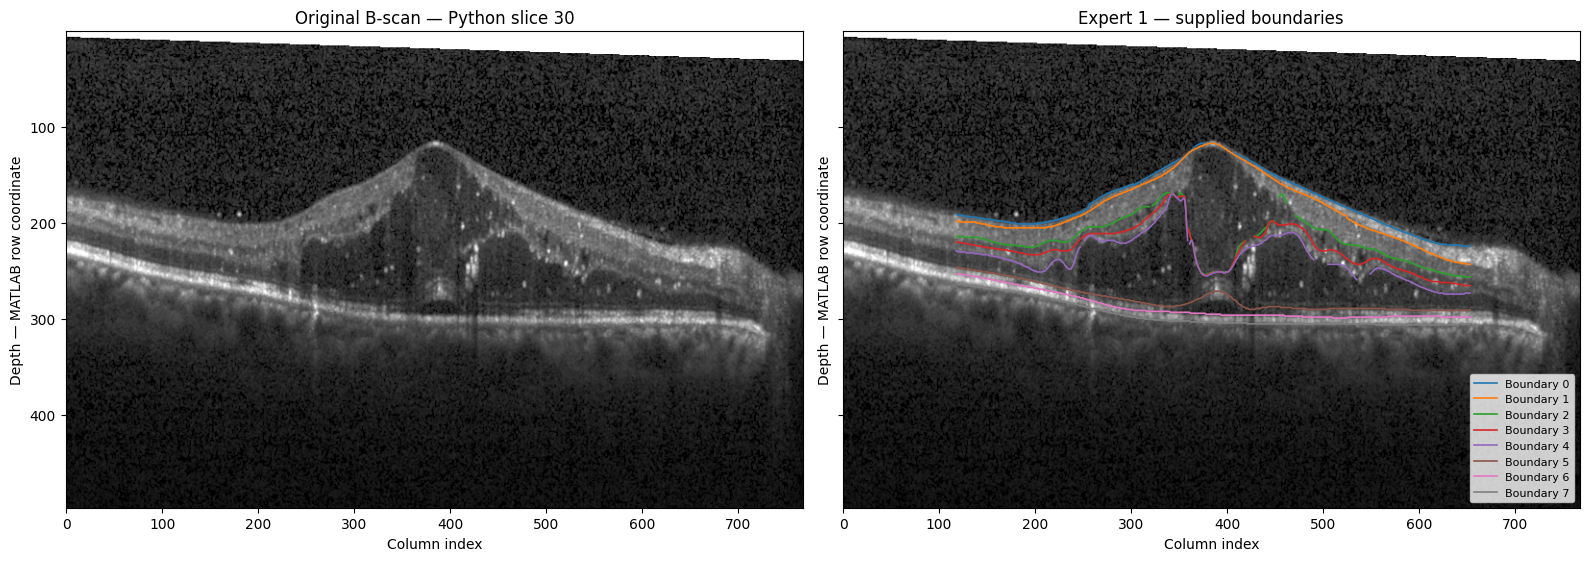

In [4]:
import matplotlib.pyplot as plt

# Choose the middle entry among annotated slices.
slice_idx = int(annotated_slices[len(annotated_slices) // 2])

bscan = images[:, :, slice_idx]

# Keep missing and out-of-range coordinates as NaN.
curves = np.where(
    valid[:, :, slice_idx],
    layers[:, :, slice_idx],
    np.nan,
)

x = np.arange(width)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    sharex=True,
    sharey=True,
)

# Display pixel centres at rows 1..height, matching the candidate
# MATLAB coordinate convention without modifying the annotations.
image_extent = (-0.5, width - 0.5, height + 0.5, 0.5)

for ax in axes:
    ax.imshow(
        bscan,
        cmap="gray",
        origin="upper",
        extent=image_extent,
        vmin=0,
        vmax=255,
    )
    ax.set_xlabel("Column index")
    ax.set_ylabel("Depth — MATLAB row coordinate")

axes[0].set_title(f"Original B-scan — Python slice {slice_idx}")

colors = plt.get_cmap("tab10").colors

for boundary_idx, curve in enumerate(curves):
    axes[1].plot(
        x,
        curve,
        color=colors[boundary_idx],
        linewidth=1.2,
        label=f"Boundary {boundary_idx}",
    )

axes[1].set_title("Expert 1 — supplied boundaries")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
ILM_INDEX = 0
NFL_GCL_INDEX = 1

BACKGROUND = 0
NFL = 1
IGNORE = 2

# Convert MATLAB row coordinates to zero-based Python coordinates.
top = layers[ILM_INDEX, :, slice_idx].copy() - 1.0
bottom = layers[NFL_GCL_INDEX, :, slice_idx].copy() - 1.0

# Both boundaries must be present and within the image.
pair_present = (
    valid[ILM_INDEX, :, slice_idx]
    & valid[NFL_GCL_INDEX, :, slice_idx]
)

# Boundary depth increases downward. Crossing boundaries are invalid.
crossed = pair_present & (bottom < top)
valid_columns = pair_present & ~crossed

assert valid_columns.any(), "No usable NFL annotations in this slice."

# Preserve missing/invalid regions as NaN in the coordinate arrays.
top[~valid_columns] = np.nan
bottom[~valid_columns] = np.nan

# Broadcast row coordinates against all column-wise boundary positions.
rows = np.arange(height)[:, None]  # (height, 1)

nfl_region = (
    valid_columns[None, :]
    & (rows >= top[None, :])
    & (rows < bottom[None, :])
)

# Unknown columns must not be interpreted as known background.
label = np.full((height, width), IGNORE, dtype=np.uint8)
label[:, valid_columns] = BACKGROUND
label[nfl_region] = NFL

thickness_px = bottom - top

print(f"Selected Python slice: {slice_idx}")
print(f"Valid columns: {valid_columns.sum()} / {width}")
print(f"Crossed boundary pairs: {crossed.sum()}")
print(f"Ignored columns: {(~valid_columns).sum()}")

values, counts = np.unique(label, return_counts=True)
print("Pixel counts by label:", dict(zip(values.tolist(), counts.tolist())))

print(
    "Thickness min / median / max:",
    np.round(
        [
            np.nanmin(thickness_px),
            np.nanmedian(thickness_px),
            np.nanmax(thickness_px),
        ],
        2,
    ),
    "pixels",
)

Selected Python slice: 30
Valid columns: 536 / 768
Crossed boundary pairs: 0
Ignored columns: 232
Pixel counts by label: {0: 262307, 1: 3549, 2: 115072}
Thickness min / median / max: [ 0.  6. 19.] pixels


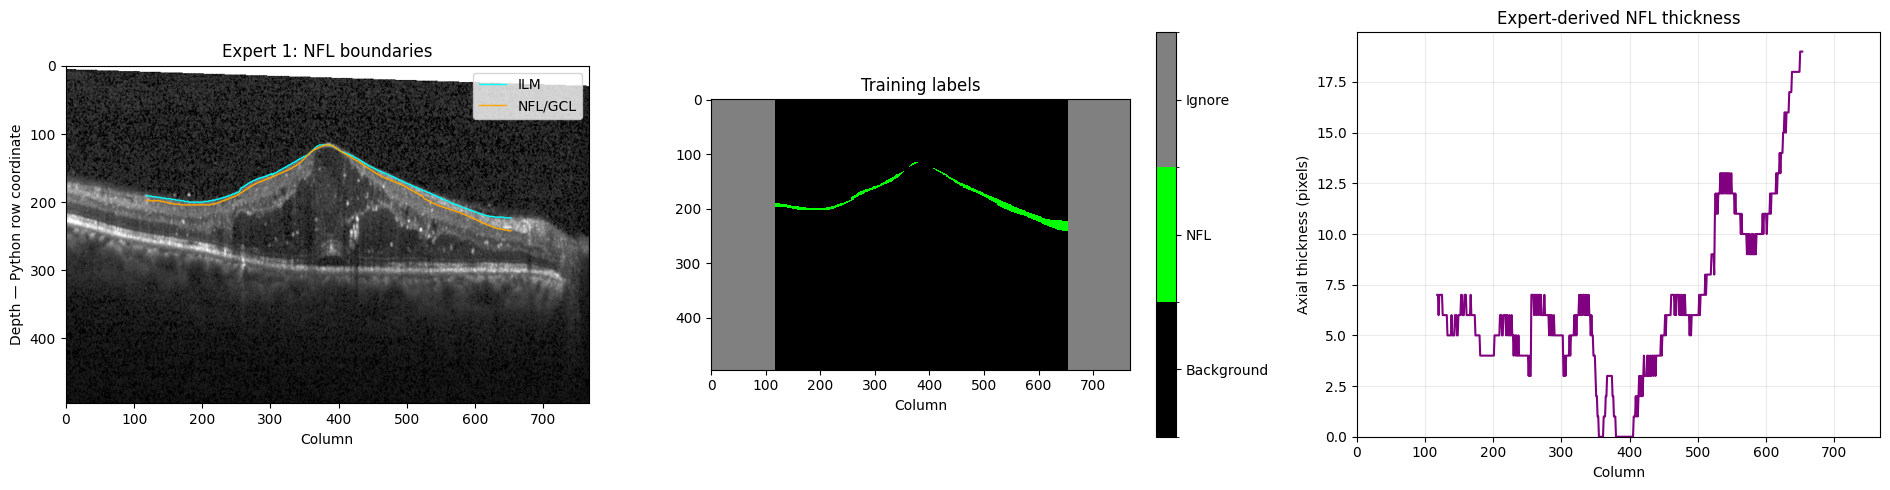

In [6]:
from matplotlib.colors import ListedColormap, BoundaryNorm

x = np.arange(width)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Panel 1: anatomical boundary placement.
axes[0].imshow(
    images[:, :, slice_idx],
    cmap="gray",
    origin="upper",
    vmin=0,
    vmax=255,
)

axes[0].plot(x, top, color="cyan", linewidth=1, label="ILM")
axes[0].plot(x, bottom, color="orange", linewidth=1, label="NFL/GCL")

axes[0].set_title("Expert 1: NFL boundaries")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Depth — Python row coordinate")
axes[0].legend()

# Panel 2: actual integer labels that will supervise the network.
label_cmap = ListedColormap(["black", "lime", "gray"])
label_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], label_cmap.N)

mask_plot = axes[1].imshow(
    label,
    cmap=label_cmap,
    norm=label_norm,
    origin="upper",
    interpolation="nearest",
)

axes[1].set_title("Training labels")
axes[1].set_xlabel("Column")

colorbar = fig.colorbar(mask_plot, ax=axes[1], ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["Background", "NFL", "Ignore"])

# Panel 3: thickness remains undefined outside valid annotation columns.
axes[2].plot(x, thickness_px, color="purple", linewidth=1.5)
axes[2].set_title("Expert-derived NFL thickness")
axes[2].set_xlabel("Column")
axes[2].set_ylabel("Axial thickness (pixels)")
axes[2].set_xlim(0, width - 1)
axes[2].set_ylim(bottom=0)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [7]:
def build_nfl_target(boundaries, image_shape):
    """
    boundaries: MATLAB row coordinates, shape (8, width).
    image_shape: (height, width).

    Returns labels, boundary coordinates, validity, and crossing flags.
    Labels: 0=background, 1=NFL, 2=ignore.
    """
    height, width = image_shape
    boundaries = np.asarray(boundaries, dtype=np.float64)

    if boundaries.shape != (8, width):
        raise ValueError(
            f"Expected boundary shape {(8, width)}, "
            f"received {boundaries.shape}"
        )

    pair = boundaries[[0, 1], :]

    present = (
        np.isfinite(pair).all(axis=0)
        & (pair >= 1).all(axis=0)
        & (pair <= height).all(axis=0)
    )

    top, bottom = pair - 1.0

    crossed = present & (bottom < top)
    valid_columns = present & ~crossed

    top = np.where(valid_columns, top, np.nan)
    bottom = np.where(valid_columns, bottom, np.nan)

    rows = np.arange(height)[:, None]

    inside_nfl = (
        valid_columns[None, :]
        & (rows >= top[None, :])
        & (rows < bottom[None, :])
    )

    labels = np.full((height, width), 2, dtype=np.uint8)
    labels[:, valid_columns] = 0
    labels[inside_nfl] = 1

    return {
        "labels": labels,
        "top": top,
        "bottom": bottom,
        "thickness_px": bottom - top,
        "valid_columns": valid_columns,
        "crossed_columns": crossed,
    }


# Verify that the reusable function reproduces our inspected example.
example = build_nfl_target(
    layers[:, :, slice_idx],
    images[:, :, slice_idx].shape,
)

assert np.array_equal(example["labels"], label)
assert np.allclose(
    example["thickness_px"],
    thickness_px,
    equal_nan=True,
)

print("Reusable conversion matches the inspected example.")

Reusable conversion matches the inspected example.


In [8]:
import pandas as pd
from tqdm.auto import tqdm

records = []

for path in tqdm(subject_files, desc="Inspecting Duke subjects"):
    data = loadmat(
        path,
        variable_names=["images", "manualLayers1"],
        squeeze_me=False,
    )

    volume = data["images"]
    annotations = data["manualLayers1"]

    if volume.ndim != 3:
        raise ValueError(f"{path.name}: unexpected image shape {volume.shape}")

    h, w, n = volume.shape

    if annotations.shape != (8, w, n):
        raise ValueError(
            f"{path.name}: incompatible annotations {annotations.shape}"
        )

    # Include scans containing any finite manual boundary annotations.
    candidates = np.flatnonzero(
        np.isfinite(annotations).any(axis=(0, 1))
    )

    for scan_idx in candidates:
        target = build_nfl_target(
            annotations[:, :, scan_idx],
            (h, w),
        )

        valid_cols = target["valid_columns"]
        thickness = target["thickness_px"][valid_cols]

        records.append({
            "case_id": f"{path.stem}_b{scan_idx:03d}",
            "subject_id": path.stem,
            "slice_index": int(scan_idx),
            "height": h,
            "width": w,
            "image_dtype": str(volume.dtype),
            "valid_columns": int(valid_cols.sum()),
            "ignored_columns": int((~valid_cols).sum()),
            "crossed_columns": int(target["crossed_columns"].sum()),
            "nfl_pixels": int((target["labels"] == 1).sum()),
            "zero_thickness_columns": int((thickness == 0).sum()),
            "median_thickness_px": (
                float(np.median(thickness)) if thickness.size else np.nan
            ),
        })

    del data, volume, annotations

manifest = pd.DataFrame(records)

assert not manifest.empty, "No annotated cases found."
assert manifest["case_id"].is_unique

summary = manifest.groupby("subject_id").agg(
    annotated_scans=("case_id", "size"),
    min_valid_columns=("valid_columns", "min"),
    max_valid_columns=("valid_columns", "max"),
    crossed_columns=("crossed_columns", "sum"),
    nfl_pixels=("nfl_pixels", "sum"),
)

print(summary.to_string())
print(f"\nTotal annotated cases: {len(manifest)}")

needs_review = manifest[
    (manifest["valid_columns"] == 0)
    | (manifest["crossed_columns"] > 0)
    | (manifest["nfl_pixels"] == 0)
]

print(f"Cases requiring review: {len(needs_review)}")
if not needs_review.empty:
    print(needs_review.to_string(index=False))

/home/btech10862.24/miniconda3/envs/oct_nfl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Inspecting Duke subjects: 100%|██████████| 10/10 [00:03<00:00,  3.13it/s]


            annotated_scans  min_valid_columns  max_valid_columns  crossed_columns  nfl_pixels
subject_id                                                                                    
Subject_01               11                522                536                0       66040
Subject_02               11                524                524                0       71582
Subject_03               11                524                524                0       66223
Subject_04               11                535                548                0       72218
Subject_05               11                530                542                0       62720
Subject_06               11                542                542                0       72752
Subject_07               11                500                500                0       51526
Subject_08               11                542                542                0       62796
Subject_09               11                506    

In [9]:
import json

subject_ids = np.array(sorted(manifest["subject_id"].unique()))

assert len(subject_ids) == 10, (
    f"Expected 10 subjects, found {len(subject_ids)}"
)

rng = np.random.default_rng(42)
shuffled = rng.permutation(subject_ids)

split = {
    "seed": 42,
    "train": sorted(shuffled[:6].tolist()),
    "val": sorted(shuffled[6:8].tolist()),
    "test": sorted(shuffled[8:].tolist()),
}

assert set(split["train"]).isdisjoint(split["val"])
assert set(split["train"]).isdisjoint(split["test"])
assert set(split["val"]).isdisjoint(split["test"])

subject_to_split = {
    subject_id: partition
    for partition in ("train", "val", "test")
    for subject_id in split[partition]
}

manifest["split"] = manifest["subject_id"].map(subject_to_split)

config_dir = PROJECT_ROOT / "configs"
audit_dir = PROJECT_ROOT / "outputs" / "audit"

config_dir.mkdir(parents=True, exist_ok=True)
audit_dir.mkdir(parents=True, exist_ok=True)

split_path = config_dir / "subject_split.json"

# Prevent accidental replacement of an established experiment split.
if split_path.exists():
    existing = json.loads(split_path.read_text())
    if existing != split:
        raise RuntimeError(
            "An existing subject split differs. Review it before proceeding."
        )
else:
    split_path.write_text(json.dumps(split, indent=2) + "\n")

manifest.to_csv(audit_dir / "duke_manifest.csv", index=False)

print(json.dumps(split, indent=2))
print("\nCase counts:")
print(manifest.groupby("split").size().to_string())

{
  "seed": 42,
  "train": [
    "Subject_01",
    "Subject_03",
    "Subject_04",
    "Subject_06",
    "Subject_07",
    "Subject_08"
  ],
  "val": [
    "Subject_05",
    "Subject_10"
  ],
  "test": [
    "Subject_02",
    "Subject_09"
  ]
}

Case counts:
split
test     22
train    66
val      22
